# Synthesize Test Claim Videos from CarDD Images

**Why:** Public datasets of realistic "claim video walkarounds" don't really exist. Rather than testing against out-of-domain footage (e.g. dashcam crash clips), we simulate a phone panning/zooming across real CarDD damage images — this keeps test videos **in-domain** for your fine-tuned model, so you're validating your pipeline logic (frame sampling, detection, aggregation, scoring) rather than fighting a domain mismatch.

**Bonus:** because we control which source images go into each video, we get a **ground-truth manifest** for free — exactly what your evaluation notebook (Notebook 4) needs to compute precision/recall on video-level output, not just per-image.

**Run this:** on Kaggle (dataset already available) or locally with the CarDD images downloaded.

**Output:** `sample_videos/*.mp4` + `sample_videos/ground_truth_manifest.json`

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("gabrielfcarvalho/cardd-with-yolo-annotations-images-labels")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/gabrielfcarvalho/cardd-with-yolo-annotations-images-labels


In [2]:
# pip install opencv-python --quiet   # run once if not already installed

import cv2
import os
import json
import random
import numpy as np
from pathlib import Path

DATASET_ROOT = '/kaggle/input/datasets/gabrielfcarvalho/cardd-with-yolo-annotations-images-labels'  # <-- edit if running elsewhere
TEST_IMG_DIR = f'{DATASET_ROOT}/test/images'
TEST_LBL_DIR = f'{DATASET_ROOT}/test/labels'

CLASS_NAMES = ['dent', 'scratch', 'crack', 'glass shatter', 'lamp broken', 'tire flat']

OUTPUT_DIR = 'sample_videos'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('Available test images:', len(os.listdir(TEST_IMG_DIR)))

Available test images: 374


## 1. Helper: Read YOLO Labels for an Image

We reuse this to know which damage classes are actually present in each source image — this becomes our ground truth.

In [3]:
def get_labels_for_image(image_filename):
    """Returns the set of damage class names present in an image, based on its YOLO label file."""
    label_path = os.path.join(TEST_LBL_DIR, os.path.splitext(image_filename)[0] + '.txt')
    classes_present = set()
    if os.path.exists(label_path):
        with open(label_path) as f:
            for line in f.readlines():
                if line.strip():
                    cls_id = int(line.split()[0])
                    classes_present.add(CLASS_NAMES[cls_id])
    return classes_present


def find_images_with_class(target_class, max_results=10):
    """Scan test images and return filenames whose labels include target_class."""
    matches = []
    for img_file in os.listdir(TEST_IMG_DIR):
        if target_class in get_labels_for_image(img_file):
            matches.append(img_file)
        if len(matches) >= max_results:
            break
    return matches


def find_images_with_no_damage_label():
    """Images with an empty or missing label file — useful as 'clean car' negative test cases.
    Note: CarDD is a damage-focused dataset, so truly damage-free images may be rare/absent.
    If none are found, we'll note this as a known dataset limitation in the eval notebook.
    """
    clean = []
    for img_file in os.listdir(TEST_IMG_DIR):
        if len(get_labels_for_image(img_file)) == 0:
            clean.append(img_file)
    return clean


clean_images = find_images_with_no_damage_label()
print(f'Found {len(clean_images)} images with no labeled damage (candidates for negative test videos).')

Found 0 images with no labeled damage (candidates for negative test videos).


## 2. Ken Burns-Style Pan/Zoom Video Generator

Simulates a phone slowly panning/zooming across a static photo — much closer to real inspection footage than a static image, and forces your frame-sampling logic to deal with continuously changing frames like a real video would.

In [5]:
def ken_burns_clip_frames(image, duration_sec=3, fps=30, zoom_start=1.0, zoom_end=1.25, pan_direction='center'):
    """Generate a list of frames simulating a slow zoom/pan across a static image.
    pan_direction: 'center', 'left_to_right', 'top_to_bottom'
    """
    h, w = image.shape[:2]
    n_frames = int(duration_sec * fps)
    frames = []

    for i in range(n_frames):
        t = i / max(n_frames - 1, 1)  # 0 -> 1 progress
        zoom = zoom_start + (zoom_end - zoom_start) * t

        crop_w = int(w / zoom)
        crop_h = int(h / zoom)

        if pan_direction == 'left_to_right':
            max_x_offset = w - crop_w
            x_offset = int(max_x_offset * t)
            y_offset = (h - crop_h) // 2
        elif pan_direction == 'top_to_bottom':
            max_y_offset = h - crop_h
            x_offset = (w - crop_w) // 2
            y_offset = int(max_y_offset * t)
        else:  # center zoom
            x_offset = (w - crop_w) // 2
            y_offset = (h - crop_h) // 2

        cropped = image[y_offset:y_offset + crop_h, x_offset:x_offset + crop_w]
        resized = cv2.resize(cropped, (w, h))
        frames.append(resized)

    return frames


def build_walkaround_video(image_filenames, output_path, fps=30, seconds_per_image=3):
    """Chain several images together with pan/zoom, simulating someone walking around
    a car and pausing on each damaged area.
    """
    pan_options = ['center', 'left_to_right', 'top_to_bottom']
    all_frames = []
    target_size = None

    for idx, img_file in enumerate(image_filenames):
        img_path = os.path.join(TEST_IMG_DIR, img_file)
        img = cv2.imread(img_path)
        if img is None:
            continue

        if target_size is None:
            target_size = (img.shape[1], img.shape[0])  # (w, h) of first image, others resized to match
        else:
            img = cv2.resize(img, target_size)

        pan = random.choice(pan_options)
        clip_frames = ken_burns_clip_frames(img, duration_sec=seconds_per_image, fps=fps, pan_direction=pan)
        all_frames.extend(clip_frames)

    if not all_frames:
        print(f'No frames generated for {output_path} — skipping.')
        return False

    h, w = all_frames[0].shape[:2]
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    writer = cv2.VideoWriter(output_path, fourcc, fps, (w, h))
    for frame in all_frames:
        writer.write(frame)
    writer.release()
    return True

## 3. Build a Proper Test Dataset (not just a handful of clips)

Target: **~25-30 videos** with real coverage, so Notebook 4's precision/recall numbers actually mean something.

- **Per-class videos** — 2 variants per damage class (6 classes × 2 = 12), each built from a *different* image subset where enough source images exist, so we're not just replaying the same 3 photos with new pan/zoom.
- **Pairwise combo videos** — one video per two-damage-type pair (e.g. dent+scratch, crack+glass shatter) to specifically stress-test multi-class detection in a single claim.
- **Mixed "realistic claim" videos** — 6 videos with 3-6 randomly chained damaged images each, simulating a real walkaround.
- **Negative/clean videos** — as many as CarDD's test set allows (likely few/none — CarDD is damage-focused; we log this as a known limitation rather than fake it).
- **Edge cases** — one long walkaround (8-10 images) and one single-image video, to check your pipeline doesn't break at the extremes.

All of this is seeded (`random.seed`) so it's reproducible, and every video still gets a ground-truth manifest entry.

In [6]:
random.seed(42)  # reproducible video generation

manifest = {}

ALL_CLASSES = CLASS_NAMES  # ['dent', 'scratch', 'crack', 'glass shatter', 'lamp broken', 'tire flat']

# How many videos per damage class, and how many source images to use per video.
VARIANTS_PER_CLASS = 2
IMAGES_PER_SINGLE_CLASS_VIDEO = 3

# Pairs of classes to explicitly combine into "multi-damage-type" videos.
CLASS_PAIRS = [
    ('dent', 'scratch'),
    ('crack', 'glass shatter'),
    ('scratch', 'crack'),
    ('dent', 'tire flat'),
    ('lamp broken', 'scratch'),
    ('dent', 'crack'),
]

N_MIXED_VIDEOS = 6
MIXED_IMAGE_RANGE = (3, 6)  # random.randint range of images per mixed video

N_LONG_WALKAROUND_IMAGES = 9  # edge case: long video


def get_all_images_with_class(target_class):
    """Full (not truncated) list of image filenames containing target_class."""
    matches = []
    for img_file in os.listdir(TEST_IMG_DIR):
        if target_class in get_labels_for_image(img_file):
            matches.append(img_file)
    return matches


def get_images_with_all_classes(target_classes, max_results=20):
    """Images whose labels include ALL of target_classes (for tight pair videos).
    Falls back to ANY-of-classes pooling if no single image has both.
    """
    both = []
    for img_file in os.listdir(TEST_IMG_DIR):
        labels = get_labels_for_image(img_file)
        if all(c in labels for c in target_classes):
            both.append(img_file)
        if len(both) >= max_results:
            break
    return both


def add_to_manifest(video_name, source_images, video_type):
    expected_classes = set()
    for img in source_images:
        expected_classes.update(get_labels_for_image(img))
    manifest[video_name] = {
        'source_images': source_images,
        'expected_damage_types': sorted(expected_classes),
        'video_type': video_type
    }
    print(f'Built {video_name} ({video_type}) -> expected: {sorted(expected_classes)}')


# Pre-shuffle each class's full image pool once, so successive variants pull
# different (non-overlapping where possible) slices instead of repeating.
class_pools = {cls: get_all_images_with_class(cls) for cls in ALL_CLASSES}
for cls, pool in class_pools.items():
    random.shuffle(pool)
    print(f'{cls}: {len(pool)} candidate images')


dent: 157 candidate images
scratch: 183 candidate images
crack: 48 candidate images
glass shatter: 71 candidate images
lamp broken: 65 candidate images
tire flat: 31 candidate images


In [7]:
# --- Single-damage-type videos: multiple variants per class ---
for cls in ALL_CLASSES:
    pool = class_pools.get(cls, [])
    if not pool:
        print(f'No images found for class "{cls}" -- skipping all variants.')
        continue

    for variant in range(VARIANTS_PER_CLASS):
        start = (variant * IMAGES_PER_SINGLE_CLASS_VIDEO) % max(len(pool), 1)
        # slice with wraparound so we still get IMAGES_PER_SINGLE_CLASS_VIDEO images
        # even if the pool is smaller than variants*images would otherwise need
        candidates = (pool[start:] + pool[:start])[:IMAGES_PER_SINGLE_CLASS_VIDEO]
        if not candidates:
            continue

        video_name = f'claim_single_{cls.replace(" ", "_")}_v{variant+1}.mp4'
        output_path = os.path.join(OUTPUT_DIR, video_name)

        success = build_walkaround_video(candidates, output_path, seconds_per_image=3)
        if success:
            add_to_manifest(video_name, candidates, 'single_class_focus')


Built claim_single_dent_v1.mp4 (single_class_focus) -> expected: ['dent', 'lamp broken', 'scratch']
Built claim_single_dent_v2.mp4 (single_class_focus) -> expected: ['crack', 'dent', 'scratch']
Built claim_single_scratch_v1.mp4 (single_class_focus) -> expected: ['crack', 'dent', 'lamp broken', 'scratch']
Built claim_single_scratch_v2.mp4 (single_class_focus) -> expected: ['dent', 'lamp broken', 'scratch']
Built claim_single_crack_v1.mp4 (single_class_focus) -> expected: ['crack', 'dent', 'lamp broken', 'scratch']
Built claim_single_crack_v2.mp4 (single_class_focus) -> expected: ['crack', 'dent', 'lamp broken', 'scratch']
Built claim_single_glass_shatter_v1.mp4 (single_class_focus) -> expected: ['glass shatter']
Built claim_single_glass_shatter_v2.mp4 (single_class_focus) -> expected: ['glass shatter']
Built claim_single_lamp_broken_v1.mp4 (single_class_focus) -> expected: ['crack', 'lamp broken']
Built claim_single_lamp_broken_v2.mp4 (single_class_focus) -> expected: ['dent', 'lamp bro

In [8]:
# --- Pairwise multi-damage-type videos: stress-test multi-class detection ---
for cls_a, cls_b in CLASS_PAIRS:
    both = get_images_with_all_classes([cls_a, cls_b], max_results=6)

    if len(both) >= 2:
        candidates = both[:3]
        note = 'both_classes_same_image'
    else:
        # Fall back to chaining separate images of each class together --
        # still a valid multi-class-in-one-claim test, just across frames
        # instead of within a single frame.
        pool_a = class_pools.get(cls_a, [])
        pool_b = class_pools.get(cls_b, [])
        candidates = (pool_a[:2] + pool_b[:2])
        note = 'classes_chained_across_frames'

    if not candidates:
        print(f'No images found for pair ({cls_a}, {cls_b}) -- skipping.')
        continue

    pair_tag = f'{cls_a.replace(" ", "_")}_{cls_b.replace(" ", "_")}'
    video_name = f'claim_pair_{pair_tag}.mp4'
    output_path = os.path.join(OUTPUT_DIR, video_name)

    success = build_walkaround_video(candidates, output_path, seconds_per_image=2.5)
    if success:
        add_to_manifest(video_name, candidates, f'pairwise_combo ({note})')


Built claim_pair_dent_scratch.mp4 (pairwise_combo (both_classes_same_image)) -> expected: ['dent', 'lamp broken', 'scratch']
Built claim_pair_crack_glass_shatter.mp4 (pairwise_combo (both_classes_same_image)) -> expected: ['crack', 'dent', 'glass shatter', 'lamp broken', 'scratch']
Built claim_pair_scratch_crack.mp4 (pairwise_combo (both_classes_same_image)) -> expected: ['crack', 'dent', 'lamp broken', 'scratch']
Built claim_pair_dent_tire_flat.mp4 (pairwise_combo (both_classes_same_image)) -> expected: ['dent', 'scratch', 'tire flat']
Built claim_pair_lamp_broken_scratch.mp4 (pairwise_combo (both_classes_same_image)) -> expected: ['crack', 'dent', 'lamp broken', 'scratch']
Built claim_pair_dent_crack.mp4 (pairwise_combo (both_classes_same_image)) -> expected: ['crack', 'dent', 'lamp broken', 'scratch']


In [9]:
# --- Mixed "realistic multi-angle claim" videos ---
all_test_images = os.listdir(TEST_IMG_DIR)
damaged_images = [f for f in all_test_images if len(get_labels_for_image(f)) > 0]
random.shuffle(damaged_images)

for i in range(N_MIXED_VIDEOS):
    n_images = random.randint(*MIXED_IMAGE_RANGE)
    mixed_sample = random.sample(damaged_images, min(n_images, len(damaged_images)))
    video_name = f'claim_mixed_{i+1}.mp4'
    output_path = os.path.join(OUTPUT_DIR, video_name)

    success = build_walkaround_video(mixed_sample, output_path, seconds_per_image=2.5)
    if success:
        add_to_manifest(video_name, mixed_sample, 'mixed_realistic_claim')


Built claim_mixed_1.mp4 (mixed_realistic_claim) -> expected: ['crack', 'dent', 'lamp broken', 'scratch']
Built claim_mixed_2.mp4 (mixed_realistic_claim) -> expected: ['dent', 'glass shatter', 'lamp broken', 'scratch', 'tire flat']
Built claim_mixed_3.mp4 (mixed_realistic_claim) -> expected: ['crack', 'dent', 'scratch']
Built claim_mixed_4.mp4 (mixed_realistic_claim) -> expected: ['dent', 'lamp broken', 'scratch']
Built claim_mixed_5.mp4 (mixed_realistic_claim) -> expected: ['crack', 'glass shatter', 'scratch']
Built claim_mixed_6.mp4 (mixed_realistic_claim) -> expected: ['dent', 'glass shatter', 'scratch']


In [10]:
# --- Clean / no-damage negative test videos (if available) ---
if clean_images:
    random.shuffle(clean_images)
    n_negatives = min(3, len(clean_images) // 2) or (1 if len(clean_images) >= 2 else 0)
    n_negatives = max(n_negatives, 1) if clean_images else 0

    used = 0
    idx = 0
    for neg_i in range(n_negatives):
        chunk = clean_images[idx: idx + 3] or clean_images[:3]
        idx += 3
        if not chunk:
            break
        video_name = f'claim_clean_no_damage_{neg_i+1}.mp4'
        output_path = os.path.join(OUTPUT_DIR, video_name)

        success = build_walkaround_video(chunk, output_path, seconds_per_image=3)
        if success:
            add_to_manifest(video_name, chunk, 'negative_control')
            used += 1
    print(f'Built {used} negative/clean video(s) from {len(clean_images)} available clean images.')
else:
    print('No clean/undamaged images found in CarDD test set -- CarDD is damage-focused, so this is expected.')
    print('Known limitation to note in your eval notebook: no true negative video available from this dataset;')
    print('recommend supplementing with 1-2 self-recorded clean-car clips for a genuine false-positive check.')


No clean/undamaged images found in CarDD test set -- CarDD is damage-focused, so this is expected.
Known limitation to note in your eval notebook: no true negative video available from this dataset;
recommend supplementing with 1-2 self-recorded clean-car clips for a genuine false-positive check.


In [11]:
# --- Edge cases: a long multi-stop walkaround, and a single-image video ---

# Long walkaround: stresses frame-sampling/dedup logic over a longer, more
# "realistic inspection" length video with many distinct damage instances.
long_pool = [img for img in os.listdir(TEST_IMG_DIR) if len(get_labels_for_image(img)) > 0]
random.shuffle(long_pool)
long_sample = long_pool[:N_LONG_WALKAROUND_IMAGES]

if long_sample:
    video_name = 'claim_edge_long_walkaround.mp4'
    output_path = os.path.join(OUTPUT_DIR, video_name)
    success = build_walkaround_video(long_sample, output_path, seconds_per_image=2)
    if success:
        add_to_manifest(video_name, long_sample, 'edge_case_long_walkaround')

# Single-image video: checks the pipeline doesn't assume >1 source image.
single_img_pool = [img for img in os.listdir(TEST_IMG_DIR) if len(get_labels_for_image(img)) > 0]
if single_img_pool:
    solo = [random.choice(single_img_pool)]
    video_name = 'claim_edge_single_image.mp4'
    output_path = os.path.join(OUTPUT_DIR, video_name)
    success = build_walkaround_video(solo, output_path, seconds_per_image=4)
    if success:
        add_to_manifest(video_name, solo, 'edge_case_single_image')

print(f'\nTotal videos generated so far: {len(manifest)}')


Built claim_edge_long_walkaround.mp4 (edge_case_long_walkaround) -> expected: ['crack', 'dent', 'lamp broken', 'scratch', 'tire flat']
Built claim_edge_single_image.mp4 (edge_case_single_image) -> expected: ['crack', 'scratch']

Total videos generated so far: 26


## 4. Save Ground Truth Manifest

In [12]:
manifest_path = os.path.join(OUTPUT_DIR, 'ground_truth_manifest.json')
with open(manifest_path, 'w') as f:
    json.dump(manifest, f, indent=2)

print(f'\nSaved manifest with {len(manifest)} videos to {manifest_path}')

# Breakdown by video_type, so you can eyeball dataset composition at a glance
from collections import Counter
type_counts = Counter(info['video_type'].split(' (')[0] for info in manifest.values())
print('\nComposition:')
for vtype, count in type_counts.most_common():
    print(f'  {vtype}: {count}')

# Damage-class coverage: how many videos touch each class at least once
class_coverage = Counter()
for info in manifest.values():
    for c in info['expected_damage_types']:
        class_coverage[c] += 1
print('\nDamage-class coverage (videos containing each class):')
for c in CLASS_NAMES:
    print(f'  {c}: {class_coverage.get(c, 0)} video(s)')

print('\nFull manifest:')
for name, info in manifest.items():
    print(f"  {name}: {info['video_type']} -> {info['expected_damage_types']}")



Saved manifest with 26 videos to sample_videos/ground_truth_manifest.json

Composition:
  single_class_focus: 12
  pairwise_combo: 6
  mixed_realistic_claim: 6
  edge_case_long_walkaround: 1
  edge_case_single_image: 1

Damage-class coverage (videos containing each class):
  dent: 20 video(s)
  scratch: 21 video(s)
  crack: 14 video(s)
  glass shatter: 6 video(s)
  lamp broken: 16 video(s)
  tire flat: 5 video(s)

Full manifest:
  claim_single_dent_v1.mp4: single_class_focus -> ['dent', 'lamp broken', 'scratch']
  claim_single_dent_v2.mp4: single_class_focus -> ['crack', 'dent', 'scratch']
  claim_single_scratch_v1.mp4: single_class_focus -> ['crack', 'dent', 'lamp broken', 'scratch']
  claim_single_scratch_v2.mp4: single_class_focus -> ['dent', 'lamp broken', 'scratch']
  claim_single_crack_v1.mp4: single_class_focus -> ['crack', 'dent', 'lamp broken', 'scratch']
  claim_single_crack_v2.mp4: single_class_focus -> ['crack', 'dent', 'lamp broken', 'scratch']
  claim_single_glass_shatte

## 5. Sanity Check: Preview One Generated Video's Frames

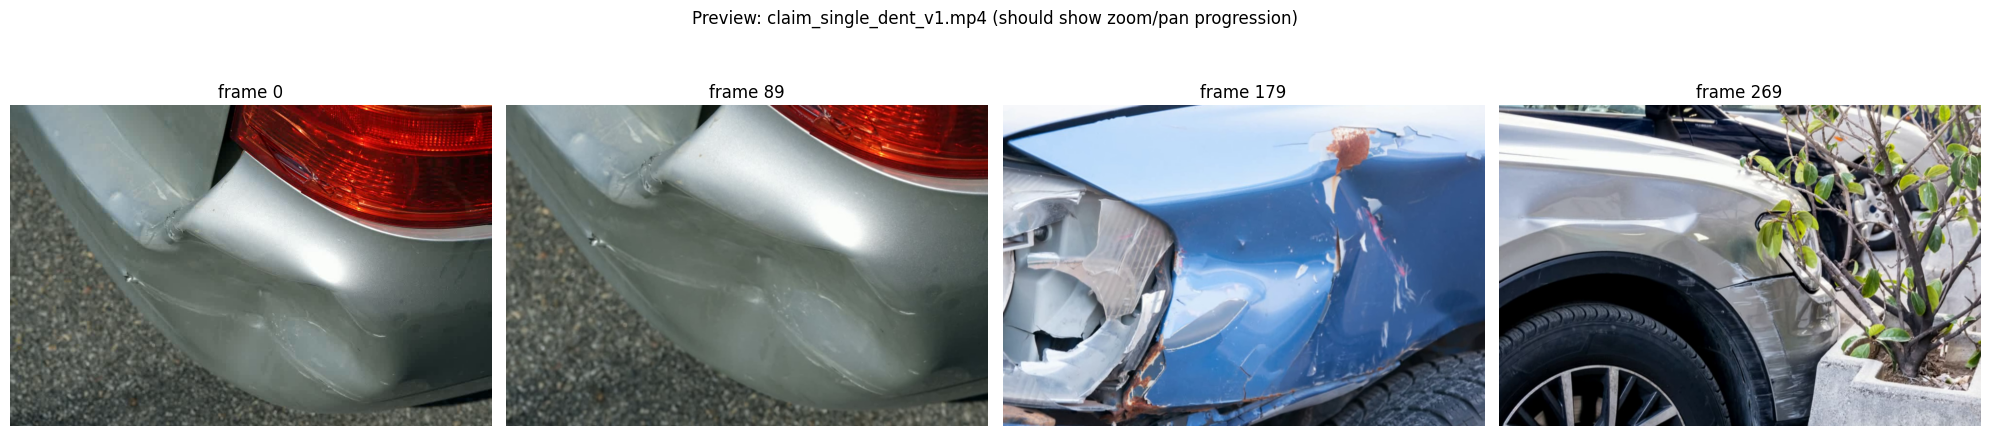

In [13]:
import matplotlib.pyplot as plt

preview_video = list(manifest.keys())[0]
preview_path = os.path.join(OUTPUT_DIR, preview_video)

cap = cv2.VideoCapture(preview_path)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
sample_indices = np.linspace(0, total_frames - 1, 4, dtype=int)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, idx in zip(axes, sample_indices):
    cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
    ret, frame = cap.read()
    if ret:
        ax.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        ax.set_title(f'frame {idx}')
        ax.axis('off')
cap.release()
plt.suptitle(f'Preview: {preview_video} (should show zoom/pan progression)')
plt.tight_layout()
plt.show()

## 6. Download / Move Videos

Zip up the `sample_videos/` folder and bring it into your local project for Notebook 2 (claim video pipeline) and Notebook 4 (evaluation).

In [14]:
import shutil
shutil.make_archive('sample_videos_bundle', 'zip', OUTPUT_DIR)
print('Zipped to sample_videos_bundle.zip — download this and unzip into your local project as sample_videos/')

# Colab:
# from google.colab import files
# files.download('sample_videos_bundle.zip')

Zipped to sample_videos_bundle.zip — download this and unzip into your local project as sample_videos/


## Important Note for Your Demo / Report

Be transparent about this being **synthetic test data** (panned/zoomed static images, not genuine handheld video) — this is a legitimate and common technique for prototype validation when no real-world dataset exists, but call it out explicitly:

> "Due to the absence of public real-world insurance claim video datasets, test videos were synthesized from CarDD's labeled damage images using simulated pan/zoom motion, providing controlled ground truth for pipeline validation. Real handheld footage was also tested qualitatively (see self-recorded samples) to validate performance under authentic camera motion, lighting, and angle variation."

This framing is a strength, not a weakness — it shows you understand the difference between validation data and production data, and that you've planned around a real constraint (no available real-world dataset) rather than ignoring it.

In [15]:
# Run once — installs the offline TTS backend (no internet needed after this point)
!apt-get -qq install -y espeak espeak-data libespeak1 > /dev/null 2>&1
!pip install pyttsx3 moviepy --quiet

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mne 1.12.1 requires decorator>=5.1, but you have decorator 4.4.2 which is incompatible.


In [16]:
import pyttsx3
import json
import os
import random
import wave
import contextlib
from moviepy.editor import VideoFileClip, AudioFileClip, ImageClip, concatenate_videoclips, CompositeAudioClip, AudioClip

SAMPLE_VIDEOS_DIR = 'sample_videos'
MANIFEST_PATH = os.path.join(SAMPLE_VIDEOS_DIR, 'ground_truth_manifest.json')

with open(MANIFEST_PATH) as f:
    manifest = json.load(f)

print(f'Loaded manifest with {len(manifest)} videos.')

/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:294: SyntaxWarning: invalid escape sequence '\d'
  lines_video = [l for l in lines if ' Video: ' in l and re.search('\d+x\d+', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:367: SyntaxWarning: invalid escape sequence '\d'
  rotation_lines = [l for l in lines if 'rotate          :' in l and re.search('\d+$', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:370: SyntaxWarning: invalid escape sequence '\d'
  match = re.search('\d+$', rotation_line)
error: XDG_RUNTIME_DIR not set in the environment.
ALSA lib confmisc.c:855:(parse_card) cannot find card '0'
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_card_inum returned error: No such file or directory
A

Loaded manifest with 26 videos.


In [21]:
CALM_TEMPLATES = [
    "Hi, I'm filing a claim for my vehicle. There's {damage_list}. It happened yesterday in the parking lot.",
    "I wanted to report some damage to my car. You can see {damage_list} on the vehicle. I have photos attached.",
    "This is regarding my recent claim. The car has {damage_list}. Please let me know the next steps."
]

DISTRESSED_TEMPLATES = [
    "Um, hi, so, uh, my car got, um, damaged. There's, uh, {damage_list}, I think. It happened, um, really fast, I didn't really see it coming.",
    "I, uh, I'm not really sure what happened exactly, but, um, there's {damage_list} now. It's, uh, pretty stressful, honestly.",
    "So, um, this is really frustrating, but, uh, my vehicle has {damage_list}. I, um, I just want this resolved quickly, uh, if possible."
]

NO_DAMAGE_TEMPLATE = "Hi, I'm just doing a routine check-in on my vehicle. Everything looks fine, no new damage to report."


def format_damage_list(damage_types):
    if not damage_types:
        return None
    if len(damage_types) == 1:
        return f'a {damage_types[0]}'
    return ', '.join(damage_types[:-1]) + f', and a {damage_types[-1]}'


def generate_narration(damage_types, style):
    if not damage_types:
        return NO_DAMAGE_TEMPLATE

    damage_list = format_damage_list(damage_types)
    template = random.choice(CALM_TEMPLATES if style == 'calm' else DISTRESSED_TEMPLATES)
    return template.format(damage_list=damage_list)

In [22]:
random.seed(7)

video_names = list(manifest.keys())
styles = ['calm', 'distressed'] * (len(video_names) // 2 + 1)
random.shuffle(styles)

for video_name, style in zip(video_names, styles):
    manifest[video_name]['narration_style'] = style
    manifest[video_name]['narration_text'] = generate_narration(
        manifest[video_name]['expected_damage_types'], style
    )

for name, info in manifest.items():
    print(f"{name} [{info['narration_style']}]: {info['narration_text']}")

claim_single_dent_v1.mp4 [distressed]: So, um, this is really frustrating, but, uh, my vehicle has dent, lamp broken, and a scratch. I, um, I just want this resolved quickly, uh, if possible.
claim_single_dent_v2.mp4 [distressed]: So, um, this is really frustrating, but, uh, my vehicle has crack, dent, and a scratch. I, um, I just want this resolved quickly, uh, if possible.
claim_single_scratch_v1.mp4 [calm]: I wanted to report some damage to my car. You can see crack, dent, lamp broken, and a scratch on the vehicle. I have photos attached.
claim_single_scratch_v2.mp4 [calm]: Hi, I'm filing a claim for my vehicle. There's dent, lamp broken, and a scratch. It happened yesterday in the parking lot.
claim_single_crack_v1.mp4 [distressed]: Um, hi, so, uh, my car got, um, damaged. There's, uh, crack, dent, lamp broken, and a scratch, I think. It happened, um, really fast, I didn't really see it coming.
claim_single_crack_v2.mp4 [calm]: Hi, I'm filing a claim for my vehicle. There's crack, 

In [23]:
!apt-get update -qq
!apt-get install -y espeak-ng

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  espeak-ng-data libespeak-ng1 libpcaudio0
The following NEW packages will be installed:
  espeak-ng espeak-ng-data libespeak-ng1 libpcaudio0
0 upgraded, 4 newly installed, 0 to remove and 193 not upgraded.
Need to get 4,515 kB of archives.
After this operation, 11.8 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 libpcaudio0 amd64 1.1-6build2 [8,956 B]
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 espeak-ng-data amd64 1.50+dfsg-10ubuntu0.1 [3,956 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 libespeak-ng1 amd64 1.50+dfsg-10ubuntu0.1 [207 kB]
Get:4 http://archive.u

In [28]:
!espeak-ng "This is a test of the car damage narration system." -w test.wav

In [29]:
import os

print(os.path.exists("test.wav"))
print(os.path.getsize("test.wav"))

True
121436


In [30]:
from IPython.display import Audio

Audio("test.wav")

In [31]:
import os
import subprocess


def synthesize_narration(text, style, output_wav_path):

    # Different speaking rates for different narration styles
    if style == 'distressed':
        rate = 270
    else:
        rate = 180

    subprocess.run([
        "espeak-ng",
        "-v", "en",
        "-s", str(rate),
        "-w", output_wav_path,
        text
    ], check=True)


AUDIO_DIR = 'sample_audio'
os.makedirs(AUDIO_DIR, exist_ok=True)

for video_name, info in manifest.items():

    audio_filename = os.path.splitext(video_name)[0] + '.wav'
    audio_path = os.path.join(AUDIO_DIR, audio_filename)

    synthesize_narration(
        info['narration_text'],
        info['narration_style'],
        audio_path
    )

    info['narration_audio_path'] = audio_path

    print(f'Synthesized: {audio_path}')

Synthesized: sample_audio/claim_single_dent_v1.wav
Synthesized: sample_audio/claim_single_dent_v2.wav
Synthesized: sample_audio/claim_single_scratch_v1.wav
Synthesized: sample_audio/claim_single_scratch_v2.wav
Synthesized: sample_audio/claim_single_crack_v1.wav
Synthesized: sample_audio/claim_single_crack_v2.wav
Synthesized: sample_audio/claim_single_glass_shatter_v1.wav
Synthesized: sample_audio/claim_single_glass_shatter_v2.wav
Synthesized: sample_audio/claim_single_lamp_broken_v1.wav
Synthesized: sample_audio/claim_single_lamp_broken_v2.wav
Synthesized: sample_audio/claim_single_tire_flat_v1.wav
Synthesized: sample_audio/claim_single_tire_flat_v2.wav
Synthesized: sample_audio/claim_pair_dent_scratch.wav
Synthesized: sample_audio/claim_pair_crack_glass_shatter.wav
Synthesized: sample_audio/claim_pair_scratch_crack.wav
Synthesized: sample_audio/claim_pair_dent_tire_flat.wav
Synthesized: sample_audio/claim_pair_lamp_broken_scratch.wav
Synthesized: sample_audio/claim_pair_dent_crack.wav

In [32]:
def get_wav_duration(path):
    with contextlib.closing(wave.open(path, 'r')) as f:
        frames = f.getnframes()
        rate = f.getframerate()
        return frames / float(rate)


for video_name, info in manifest.items():
    audio_dur = get_wav_duration(info['narration_audio_path'])
    video_path = os.path.join(SAMPLE_VIDEOS_DIR, video_name)
    video_dur = VideoFileClip(video_path).duration
    info['audio_duration_sec'] = round(audio_dur, 2)
    info['video_duration_sec'] = round(video_dur, 2)
    print(f'{video_name}: video={video_dur:.1f}s, audio={audio_dur:.1f}s')

claim_single_dent_v1.mp4: video=9.0s, audio=6.4s
claim_single_dent_v2.mp4: video=9.0s, audio=6.2s
claim_single_scratch_v1.mp4: video=9.0s, audio=8.2s
claim_single_scratch_v2.mp4: video=9.0s, audio=7.4s
claim_single_crack_v1.mp4: video=9.0s, audio=7.3s
claim_single_crack_v2.mp4: video=9.0s, audio=7.8s
claim_single_glass_shatter_v1.mp4: video=9.0s, audio=5.6s
claim_single_glass_shatter_v2.mp4: video=9.0s, audio=6.0s
claim_single_lamp_broken_v1.mp4: video=9.0s, audio=5.4s
claim_single_lamp_broken_v2.mp4: video=9.0s, audio=7.7s
claim_single_tire_flat_v1.mp4: video=9.0s, audio=6.4s
claim_single_tire_flat_v2.mp4: video=9.0s, audio=5.4s
claim_pair_dent_scratch.mp4: video=7.5s, audio=7.0s
claim_pair_crack_glass_shatter.mp4: video=7.5s, audio=7.3s
claim_pair_scratch_crack.mp4: video=7.5s, audio=8.2s
claim_pair_dent_tire_flat.mp4: video=7.5s, audio=6.8s
claim_pair_lamp_broken_scratch.mp4: video=7.5s, audio=7.6s
claim_pair_dent_crack.mp4: video=7.5s, audio=7.3s
claim_mixed_1.mp4: video=15.0s, aud

In [33]:
import os
import subprocess


OUTPUT_DIR_WITH_AUDIO = 'sample_videos_with_audio'
os.makedirs(OUTPUT_DIR_WITH_AUDIO, exist_ok=True)


def mux_audio_into_video(video_name, info):

    video_path = os.path.join(SAMPLE_VIDEOS_DIR, video_name)
    audio_path = info['narration_audio_path']
    output_path = os.path.join(
        OUTPUT_DIR_WITH_AUDIO,
        video_name
    )

    command = [
        "ffmpeg",
        "-y",
        "-i", video_path,
        "-i", audio_path,

        # Video
        "-c:v", "libx264",
        "-preset", "medium",
        "-pix_fmt", "yuv420p",

        # Audio
        "-c:a", "aac",
        "-b:a", "192k",

        # Make output duration equal to the longer stream
        "-shortest",

        output_path
    ]

    subprocess.run(
        command,
        check=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        text=True
    )

    return output_path
for video_name, info in manifest.items():

    out_path = mux_audio_into_video(
        video_name,
        info
    )

    info['final_video_with_audio_path'] = out_path

    print(f"Created: {out_path}")

Created: sample_videos_with_audio/claim_single_dent_v1.mp4
Created: sample_videos_with_audio/claim_single_dent_v2.mp4
Created: sample_videos_with_audio/claim_single_scratch_v1.mp4
Created: sample_videos_with_audio/claim_single_scratch_v2.mp4
Created: sample_videos_with_audio/claim_single_crack_v1.mp4
Created: sample_videos_with_audio/claim_single_crack_v2.mp4
Created: sample_videos_with_audio/claim_single_glass_shatter_v1.mp4
Created: sample_videos_with_audio/claim_single_glass_shatter_v2.mp4
Created: sample_videos_with_audio/claim_single_lamp_broken_v1.mp4
Created: sample_videos_with_audio/claim_single_lamp_broken_v2.mp4
Created: sample_videos_with_audio/claim_single_tire_flat_v1.mp4
Created: sample_videos_with_audio/claim_single_tire_flat_v2.mp4
Created: sample_videos_with_audio/claim_pair_dent_scratch.mp4
Created: sample_videos_with_audio/claim_pair_crack_glass_shatter.mp4
Created: sample_videos_with_audio/claim_pair_scratch_crack.mp4
Created: sample_videos_with_audio/claim_pair_den

In [34]:
with open(MANIFEST_PATH, 'w') as f:
    json.dump(manifest, f, indent=2)

print('Updated manifest saved with narration + audio metadata.')
print(json.dumps({k: {kk: vv for kk, vv in v.items() if kk != 'source_images'} for k, v in manifest.items()}, indent=2))

Updated manifest saved with narration + audio metadata.
{
  "claim_single_dent_v1.mp4": {
    "expected_damage_types": [
      "dent",
      "lamp broken",
      "scratch"
    ],
    "video_type": "single_class_focus",
    "narration_style": "distressed",
    "narration_text": "So, um, this is really frustrating, but, uh, my vehicle has dent, lamp broken, and a scratch. I, um, I just want this resolved quickly, uh, if possible.",
    "narration_audio_path": "sample_audio/claim_single_dent_v1.wav",
    "audio_duration_sec": 6.41,
    "video_duration_sec": 9.0,
    "final_video_with_audio_path": "sample_videos_with_audio/claim_single_dent_v1.mp4"
  },
  "claim_single_dent_v2.mp4": {
    "expected_damage_types": [
      "crack",
      "dent",
      "scratch"
    ],
    "video_type": "single_class_focus",
    "narration_style": "distressed",
    "narration_text": "So, um, this is really frustrating, but, uh, my vehicle has crack, dent, and a scratch. I, um, I just want this resolved quickl

In [35]:
from IPython.display import Video

preview_video = list(manifest.keys())[0]
preview_path = manifest[preview_video]['final_video_with_audio_path']
print(f"Previewing: {preview_video} [{manifest[preview_video]['narration_style']}]")
print(f"Narration: {manifest[preview_video]['narration_text']}")
Video(preview_path, embed=True, width=500)

Previewing: claim_single_dent_v1.mp4 [distressed]
Narration: So, um, this is really frustrating, but, uh, my vehicle has dent, lamp broken, and a scratch. I, um, I just want this resolved quickly, uh, if possible.


In [36]:
import shutil

shutil.copy(MANIFEST_PATH, os.path.join(OUTPUT_DIR_WITH_AUDIO, 'ground_truth_manifest.json'))
shutil.make_archive('sample_videos_with_audio_bundle', 'zip', OUTPUT_DIR_WITH_AUDIO)
print('Zipped to sample_videos_with_audio_bundle.zip — download and unzip locally as sample_videos_with_audio/')

# Colab:
# from google.colab import files
# files.download('sample_videos_with_audio_bundle.zip')

Zipped to sample_videos_with_audio_bundle.zip — download and unzip locally as sample_videos_with_audio/
